1. Vytvořte tabulku níže pomocí Pythonu a propojte je pomocí cizích klíčů

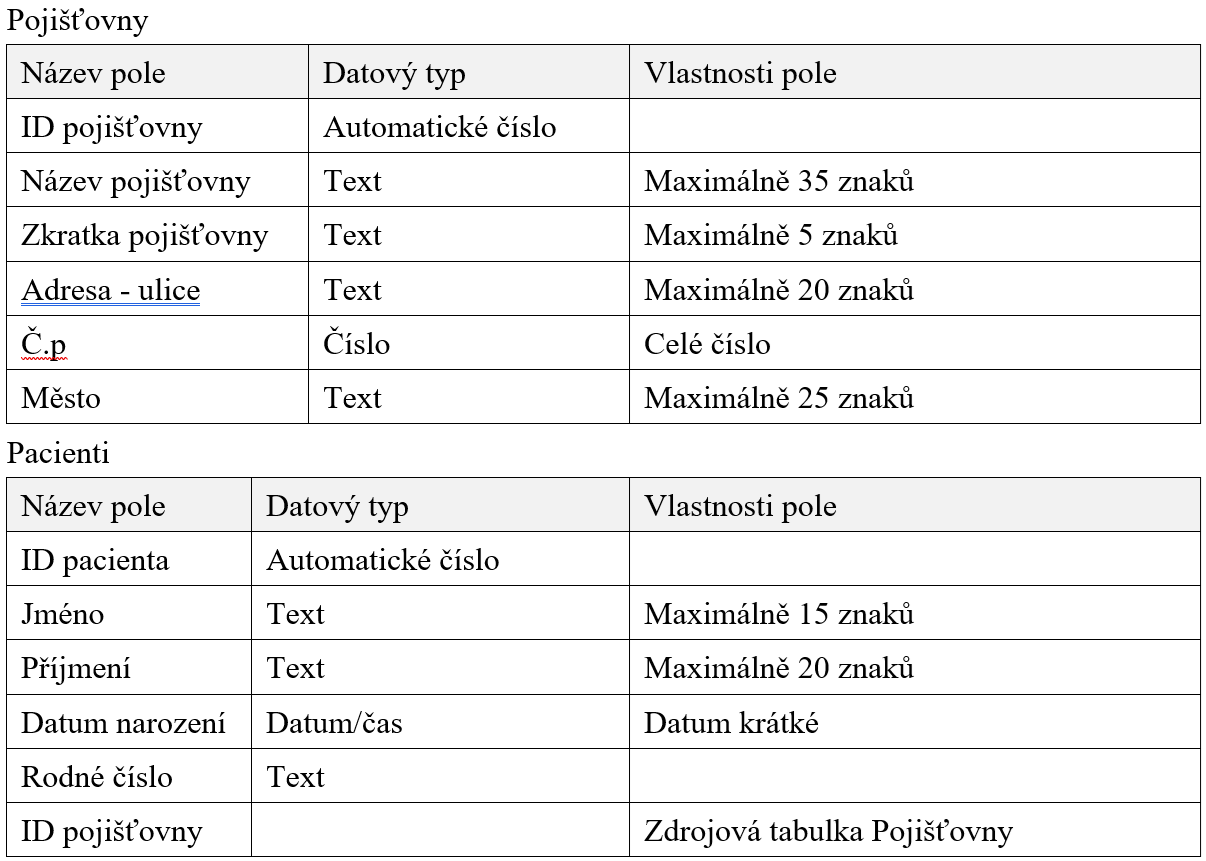

In [1]:
! pip install mysql.connector

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 68.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mysql.connector: filename=mysql_connector-2.2.9-cp310-cp310-linux_x86_64.whl size=247948 sha256=a1840e0e367582b2bc93aad4c2d5ea458a81aa48b71e6070851170134973a9fc
  Stored in directory: /root/.cache/pip/wheels/76/48/9b/da67ff1a18fe8e9d428f9b1a177716d4a7d363d2bbe83bf6cf
Successfully built mysql.connector


In [2]:
import mysql.connector
mydb = mysql.connector.connect(
    host="dbs.spskladno.cz",
    user="student24",
    password="spsnet",
    database="vyuka24"
)
mycursor = mydb.cursor()

mycursor.execute('''
    CREATE TABLE Pojišťovny (
        ID_pojistovny INTEGER PRIMARY KEY AUTO_INCREMENT,
        Nazev_pojistovny VARCHAR(35) NOT NULL,
        Zkratka_pojistovny VARCHAR(5) NOT NULL,
        Adresa_ulice VARCHAR(20),
        C_p INTEGER,
        Mesto VARCHAR(25)
    )
''')
mydb.commit()
mycursor.execute('''
    CREATE TABLE Pacienti (
        ID_pacienta INTEGER PRIMARY KEY AUTO_INCREMENT,
        Jmeno TEXT NOT NULL,
        Prijmeni TEXT NOT NULL,
        Datum_narozeni DATE,
        Rodne_cislo TEXT,
        ID_pojistovny INTEGER,
        FOREIGN KEY (ID_pojistovny) REFERENCES Pojišťovny (ID_pojistovny),
        CONSTRAINT Jmeno_length CHECK (LENGTH(Jmeno) <= 15), # Use LENGTH and separate constraint
        CONSTRAINT Prijmeni_length CHECK (LENGTH(Prijmeni) <= 20) # Use LENGTH and separate constraint
    )
''')
mydb.commit()
mycursor.close()
mydb.close()

2. Vložte do těchto tabulek tři záznamy pomocí příkazu insert

In [3]:
import mysql.connector

mydb = mysql.connector.connect(
    host="dbs.spskladno.cz",
    user="student24",
    password="spsnet",
    database="vyuka24"
)

mycursor = mydb.cursor()

sql_pojistovny = "INSERT INTO Pojišťovny (Nazev_pojistovny, Zkratka_pojistovny, Adresa_ulice, C_p, Mesto) VALUES (%s, %s, %s, %s, %s)"
pojistovny_values = [
    ('Pojišťovna A', 'PJA', 'Ulice A', 101, 'Město A'),
    ('Pojišťovna B', 'PJB', 'Ulice B', 102, 'Město B'),
    ('Pojišťovna C', 'PJC', 'Ulice C', 103, 'Město C')
]
mycursor.executemany(sql_pojistovny, pojistovny_values)

sql_pacienti = "INSERT INTO Pacienti (Jmeno, Prijmeni, Datum_narozeni, Rodne_cislo, ID_pojistovny) VALUES (%s, %s, %s, %s, %s)"
pacienti_values = [
    ('Jan', 'Novák', '1980-01-01', '8001011234', 1),
    ('Petr', 'Svoboda', '1990-02-02', '9002025678', 2),
    ('Eva', 'Zelená', '2000-03-03', '0003039876', 3)
]
mycursor.executemany(sql_pacienti, pacienti_values)

mydb.commit()

mycursor.close()
mydb.close()


3. Vypište všechny informace o prvním pacientovi

In [4]:
# TODO
import mysql.connector

mydb = mysql.connector.connect(
    host="dbs.spskladno.cz",
    user="student24",
    password="spsnet",
    database="vyuka24"
)

mycursor = mydb.cursor()

sql = "SELECT * FROM Pacienti WHERE ID_pacienta = 1"
mycursor.execute(sql)

myresult = mycursor.fetchall()

for id, Jmeno, Prijmeni, Datum_narozeni, Rodne_cislo, ID_pojistovny in myresult:
    print(f"""
    Pacient má id {id}, Jméno {Jmeno} {Prijmeni}, narozen {Datum_narozeni} rodné číslo {Rodne_cislo} Pojištovnu {ID_pojistovny}
    """)

mycursor.close()
mydb.close()



    Pacient má id 1, Jméno Jan Novák, narozen 1980-01-01 rodné číslo 8001011234 Pojištovnu 1
    


4. Vypište všechny informace o pacientech a také všechny infromace o jeho pojišťovně pomocí Joinu

In [5]:
import mysql.connector

mydb = mysql.connector.connect(
    host="dbs.spskladno.cz",
    user="student24",
    password="spsnet",
    database="vyuka24"
)
mycursor = mydb.cursor()

sql = """
SELECT
    Pacienti.ID_pacienta, Pacienti.Jmeno, Pacienti.Prijmeni, Pacienti.Datum_narozeni, Pacienti.Rodne_cislo,
    Pojišťovny.ID_pojistovny, Pojišťovny.Nazev_pojistovny, Pojišťovny.Zkratka_pojistovny,
    Pojišťovny.Adresa_ulice, Pojišťovny.C_p, Pojišťovny.Mesto
FROM Pacienti
JOIN Pojišťovny
ON Pacienti.ID_pojistovny = Pojišťovny.ID_pojistovny
"""

mycursor.execute(sql)

myresult = mycursor.fetchall()

for row in myresult:
    ID_pacienta, Jmeno, Prijmeni, Datum_narozeni, Rodne_cislo, ID_pojistovny, Nazev_pojistovny, Zkratka_pojistovny, Adresa_ulice, C_p, Mesto = row
    print(f"""
    Pacient:
    - ID: {ID_pacienta}
    - Jméno: {Jmeno} {Prijmeni}
    - Datum narození: {Datum_narozeni}
    - Rodné číslo: {Rodne_cislo}

    Pojišťovna:
    - ID pojišťovny: {ID_pojistovny}
    - Název: {Nazev_pojistovny}
    - Zkratka: {Zkratka_pojistovny}
    - Adresa: {Adresa_ulice} {C_p}, {Mesto}
    """)

mycursor.close()
mydb.close()



    Pacient:
    - ID: 1
    - Jméno: Jan Novák
    - Datum narození: 1980-01-01
    - Rodné číslo: 8001011234

    Pojišťovna:
    - ID pojišťovny: 1
    - Název: Pojišťovna A
    - Zkratka: PJA
    - Adresa: Ulice A 101, Město A
    

    Pacient:
    - ID: 2
    - Jméno: Petr Svoboda
    - Datum narození: 1990-02-02
    - Rodné číslo: 9002025678

    Pojišťovna:
    - ID pojišťovny: 2
    - Název: Pojišťovna B
    - Zkratka: PJB
    - Adresa: Ulice B 102, Město B
    

    Pacient:
    - ID: 3
    - Jméno: Eva Zelená
    - Datum narození: 2000-03-03
    - Rodné číslo: 0003039876

    Pojišťovna:
    - ID pojišťovny: 3
    - Název: Pojišťovna C
    - Zkratka: PJC
    - Adresa: Ulice C 103, Město C
    


5. Zjistěte průměrný věk pacientů

In [6]:

import mysql.connector
from datetime import date

mydb = mysql.connector.connect(
    host="dbs.spskladno.cz",
    user="student24",
    password="spsnet",
    database="vyuka24"
)

mycursor = mydb.cursor()

sql = """
SELECT Datum_narozeni
FROM Pacienti
"""

mycursor.execute(sql)

myresult = mycursor.fetchall()

ages = []
for row in myresult:
  birth_date = row[0]
  today = date.today()
  age = today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))
  ages.append(age)


if ages:
    average_age = sum(ages) / len(ages)
    average_age = round(average_age, 2)
    print(f"Průměrný věk pacientů je: {average_age:.2f} let")
else:
    print("Nejsou k dispozici žádná data o pacientech.")

mycursor.close()
mydb.close()


Průměrný věk pacientů je: 34.00 let
